# Fit of 10 Impulses on a Single Curve
This notebook demonstrates the fitting of the double rate balence equation model to a single experimental curve representing the synaptic response of PAZO to a train of 10 light pulses (impulses).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from scipy.optimize import curve_fit
from functions_general import *
%matplotlib widget

## Obtain Data

In this step, we load the preprocessed experimental data for the 10-pulse train response from a tab-separated text file. The dataset contains the time-series measurements and the corresponding intensity values. We extract the time vector and the intensity curve to be analyzed.

In [2]:
plt.close('all')
input_filename = 'IMP_10_ND0_preprocessed_data'
path_file = fr'./Input data for fitting/{input_filename}.txt'

idx_initial_curve = 1
idx_final_curve = None
data = pd.read_csv(path_file, sep='\t')
time_data = data['Time (s)'].to_numpy()
intensity_matrix = data.iloc[:, idx_initial_curve:idx_final_curve].to_numpy()
power_density_labels = data.columns[idx_initial_curve:idx_final_curve].to_numpy()
power_density_vector = [float(label.split('= ')[1].split('nW')[0]) for label in power_density_labels]

### Define Laser Pulse Train and Plot Raw Data

We define the laser stimulation profile by specifying the start time, end time, and normalized amplitude for each of the 10 light pulses (impulses). A base laser power vector is generated, and the raw intensity response of PAZO is plotted alongside the pulse train to verify the temporal alignment.

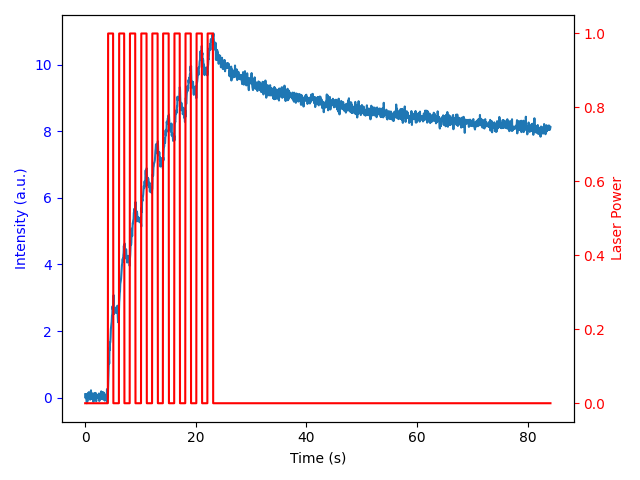

In [3]:
defined_zero = 0
laser_power_base = np.ones(len(time_data))*defined_zero

impulse_list = [
    # t1, t2, amplitude
    (4.1039, 5.10, 1.0),
    (6.111, 7.1, 1.0),
    (8.10, 9.10, 1.0),
    (10.114, 11.15, 1.0),
    (12.15, 13.15, 1.0),
    (14.10, 15.15, 1.0),
    (16.15, 17.15, 1.0),
    (18.15, 19.15, 1.0),
    (20.15, 21.15, 1.0),
    (22.15, 23.15, 1.0)
]

laser_power_base = add_pulses(impulse_list, time_data, laser_power_base)
fig, ax1 = plt.subplots()

for i in range(intensity_matrix.shape[1]):
    ax1.plot(time_data, intensity_matrix[:, i], label=f'{power_density_vector[i]} nW*um^-2')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Intensity (a.u.)', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(time_data, laser_power_base, 'r-', label='Laser Power')
ax2.set_ylabel('Laser Power', color='r')
ax2.tick_params('y', colors='r')

fig.tight_layout()
plt.show()

## 2. Prepare Data for Fitting

To prepare the data for the fitting manager, we structure the time, intensity, and laser power vectors into lists (each containing a single array representing our curve). Downsampling can be configured here if needed (currently set to a factor of 1 to keep all data points).

In [4]:
downsampling_factor = 1
time_list = []
power_list = []
intensity_list = []

for i in range(len(power_density_vector)):
    power_density = power_density_vector[i]
    t_d = time_data[::downsampling_factor]
    i_d = intensity_matrix[::downsampling_factor, i]
    p_d = power_density * laser_power_base[::downsampling_factor]
    
    time_list.append(t_d)
    intensity_list.append(i_d)
    power_list.append(p_d)

print(f"Prepared {len(intensity_list)} curves for global fitting.")

Prepared 1 curves for global fitting.


### Plot Data Before Fitting

We plot the prepared intensity curve and the normalized pulse train to confirm the dataset is correctly structured and ready for the optimization process.

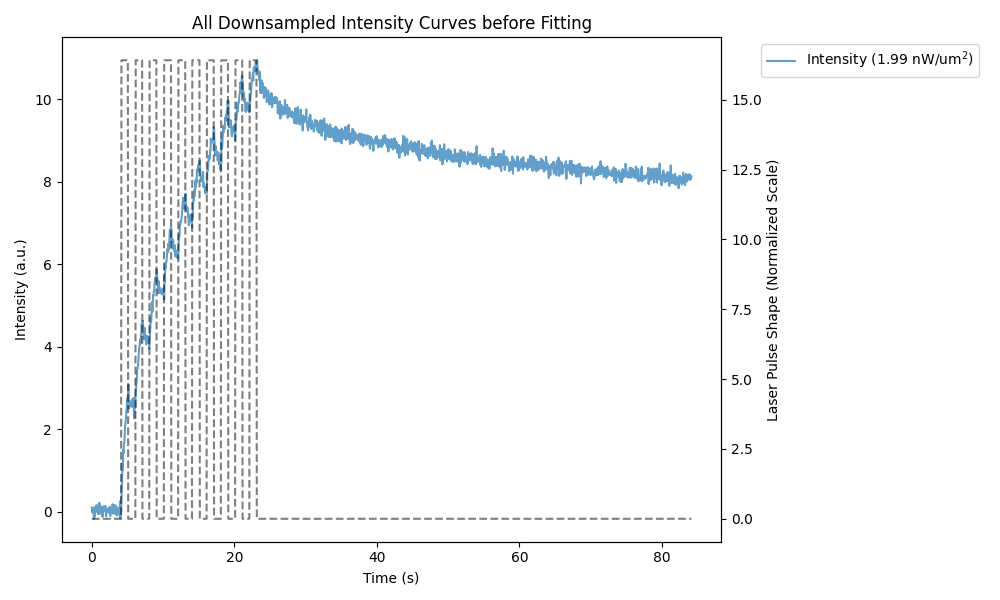

In [5]:
if intensity_list and power_list:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    for i in range(len(intensity_list)):
        t_plot = time_list[i]
        i_plot = intensity_list[i]
        power_density = power_density_vector[i]
        
        color = colors[i % len(colors)]
        ax1.plot(t_plot, i_plot, '-', 
                 label=f'Intensity ({power_density} nW/um$^2$)', 
                 alpha=0.7, color=color)

    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title('All Downsampled Intensity Curves before Fitting')
    ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    
    ax2 = ax1.twinx()
    p_ref = power_list[0]
    t_ref = time_list[0]
    
    max_p = np.max(p_ref)
    p_normalized = p_ref / max_p if max_p > 0 else np.zeros_like(p_ref)

    visualization_scale = np.max(intensity_list) * 1.5 
    ax2.plot(t_ref, p_normalized * visualization_scale, 'k--', label='Laser Pulse Shape (Scaled)', alpha=0.5)
    
    ax2.set_ylabel('Laser Pulse Shape (Normalized Scale)', color='k')
    ax2.tick_params('y', colors='k')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.05, 1))

    fig.tight_layout(rect=[0, 0, 1.0, 1])
    plt.show()

## 3. Fit Configuration

We configure the parameters for the double-rate kinetic model:
* `init_val_dict`: The initial guesses for the rate constants (`kp1`, `kd1`, `kp2`, `kd2`) and maximum currents (`Imax1`, `Imax2`).
* `var_dict`: A boolean dictionary indicating which parameters are free to be optimized (`1`) and which should remain fixed (`0`).
* `fit_global`: Since we are fitting a single curve, the parameters are local to this curve.

In [6]:
init_val_dict = {
    'kp1': 0.01,
    'kd1': 5e-6,
    'Imax1': 50,
    'kp2': 0.001,
    'kd2': 1e-15,
    'Imax2': 50
}

# 1 = fit parameter, 0 = keep fixed at initial value
var_dict = {
    'kp1': 1,
    'kd1': 1,
    'Imax1': 1,
    'kp2': 1,
    'kd2': 1,
    'Imax2': 1
}

# 1 = global parameter (shared), 0 = local parameter (independent)
fit_global = {
    'kp1': 1,
    'kd1': 1,
    'Imax1': 1,
    'kp2': 1,
    'kd2': 1,
    'Imax2': 1
}

## 4. Run the Fit

We instantiate the `GlobalFitManager` with our model function and the prepared data lists. We then execute the fit to optimize the parameters and print the resulting values alongside the $R^2$ goodness-of-fit score.

In [7]:
global_fitter = GlobalFitManager(model_fit_double_rate_dict, time_list, power_list, intensity_list)
global_fitter.setup_parameters(init_val_dict, var_dict, fit_global)
results_df = global_fitter.run_fit()

if results_df is not None:
    results_df.insert(0, 'P (nW*um^-2)', power_density_vector)
    print("Fit Results:")
    print(results_df)
    print("\nR2 error:")
    print(global_fitter.calculate_R2(results_df))

Starting global fit with 6 free parameters...
Fit completed successfully.
Fit Results:
   P (nW*um^-2)  Curve_Index       kp1       kd1     Imax1       kp2  \
0          1.99            0  3.574495  0.227603  1.469706  0.140109   

        kd2      Imax2  
0  0.002412  12.533265  

R2 error:
[0.99668157]


### Visualize Fit Results

Finally, we plot the fitted model curve against the raw experimental data to visually assess the quality and accuracy of the fit.

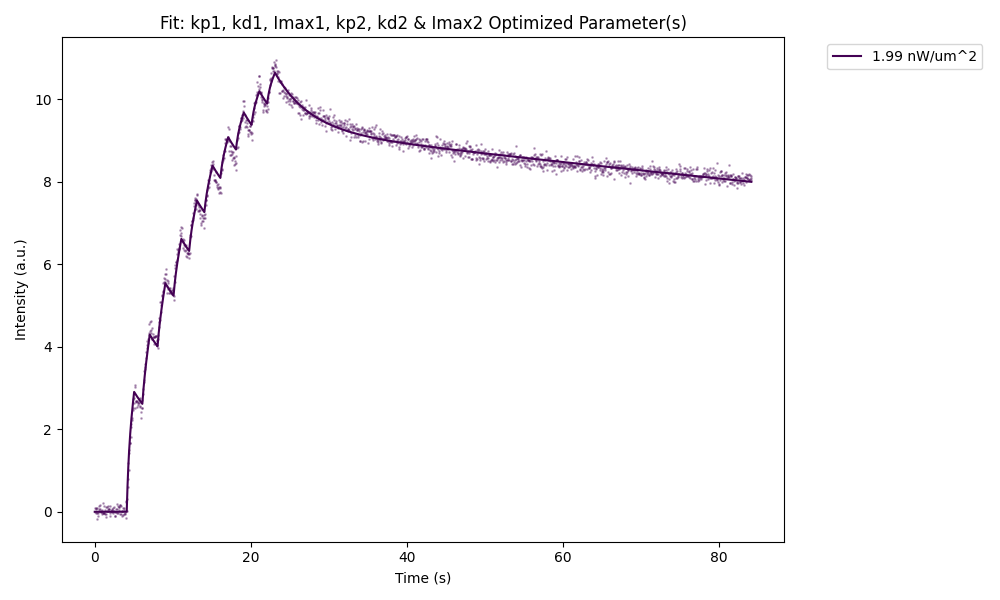

In [10]:
global_fitted_params = [
    k for k in init_val_dict.keys() 
    if var_dict.get(k, 0) == 1 and fit_global.get(k, 0) == 1
]

if global_fitted_params:
    if len(global_fitted_params) > 1:
        shared_params_str = ', '.join(global_fitted_params[:-1]) + ' & ' + global_fitted_params[-1]
    else:
        shared_params_str = global_fitted_params[0]
    dynamic_title = f'Fit: {shared_params_str} Optimized Parameter(s)'
else:
    dynamic_title = 'Single Curve Fit'

if results_df is not None:
    plt.figure(figsize=(10, 6))
    
    for i in range(len(time_list)):
        t = time_list[i]
        p = power_list[i]
        real_intensity = intensity_list[i]
        power_val = power_density_vector[i]
        
        best_params = results_df.iloc[i].to_dict()
        fit_intensity, _, _ = model_fit_double_rate_dict(t, p, best_params)
        
        color = plt.cm.viridis(i / len(time_list))
        plt.plot(t, real_intensity, '.', markersize=2, alpha=0.3, color=color)
        plt.plot(t, fit_intensity, '-', linewidth=1.5, label=f'{power_val} nW/um^2', color=color)

    plt.xlabel('Time (s)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(dynamic_title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()